### Percobaan 3
Otsu tresholding + Opening + Closing

In [2]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

mengimpor library yang digunakan. Pertama, cv2 adalah pustaka OpenCV yang digunakan untuk pemrosesan gambar dan video, sedangkan os digunakan untuk operasi sistem seperti manipulasi path file. library numpy diimpor sebagai np untuk perhitungan numerik yang efisien, sementara matplotlib.pyplot diimpor sebagai plt untuk visualisasi data dalam bentuk grafik. pandas digunakan untuk manipulasi data dan analisis dalam bentuk DataFrame, sedangkan math menyediakan fungsi matematika dasar. skimage.feature.graycomatrix dan skimage.feature.graycoprops yang bagian dari pustaka scikit-image yang digunakan untuk mengekstraksi fitur tekstur dari gambar, khususnya Gray-Level Co-occurrence Matrix (GLCM) dan propertinya. seaborn adalah pustaka visualisasi yang dibangun di atas Matplotlib, yang menyediakan antarmuka tingkat tinggi untuk membuat grafik yang lebih menarik. kemudian Scikit-Learn, beberapa metrik evaluasi seperti confusion_matrix, accuracy_score, precision_score, recall_score, dan f1_score diimpor untuk menilai performa model klasifikasi. SVC (Support Vector Classifier) diimpor untuk membuat model klasifikasi menggunakan metode Support Vector Machines. Selain itu, RandomForestClassifier dari Scikit-Learn juga diimpor untuk membuat model klasifikasi menggunakan algoritma Random Forest, yang menggabungkan beberapa pohon keputusan untuk meningkatkan akurasi prediksi.

## Data Loading

In [3]:
data = []
labels = []
file_name = []

dataset_path = "dataset/Train"

for sub_folder in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, sub_folder)

    if not os.path.isdir(full_path):
        continue  # Lewati jika bukan folder

    sub_folder_files = os.listdir(full_path)
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join(full_path, filename)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = cv2.resize(img, (256, 256))  # Resize ke ukuran tetap
            img = img.astype(np.uint8)

            data.append(img)
            labels.append(sub_folder)
            name = os.path.splitext(filename)[0]
            file_name.append(filename)

data = np.array(data)
labels = np.array(labels)

Menginisialisasi tiga list kosong, yaitu data untuk menyimpan data gambar yang diproses, labels untuk menyimpan label kelas dari setiap gambar, dan file_name untuk menyimpan nama file asli dari setiap gambar. Variabel dataset_path didefinisikan sebagai "dataset/Train", menunjukkan lokasi root dari dataset gambar untuk pelatihan. Kemudian, kode ini melakukan iterasi melalui setiap sub-folder yang ada di dalam dataset_path. Untuk setiap item dalam direktori, kode memeriksa apakah itu benar-benar sebuah folder menggunakan os.path.isdir; jika bukan, maka item tersebut dilewati. Jika itu adalah sub-folder, kode akan masuk ke loop kedua untuk membaca setiap file gambar di dalamnya. Setiap file gambar dibaca menggunakan cv2.imread, lalu diperiksa validitasnya. Jika gambar berhasil dimuat, gambar tersebut dikonversi menjadi grayscale dengan cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), diubah ukurannya menjadi $(256, 256)$ menggunakan cv2.resize untuk menyeragamkan dimensi, dan dipastikan tipe datanya berupa np.uint8. Gambar yang telah diproses ini kemudian ditambahkan ke list data, nama sub-folder ditambahkan ke list labels sebagai label kelas, dan nama file asli ditambahkan ke list file_name. Setelah semua gambar dari semua sub-folder selesai diproses, list data dan labels dikonversi menjadi array NumPy agar siap digunakan dalam proses pemodelan.

## Data Preparation

### Define Preprocessing

Kode tersebut terdiri dari beberapa fungsi pemrosesan citra untuk melakukan segmentasi biner dan operasi morfologi menggunakan matriks kernel 5 x 5 sebagai elemen strukturnya. Selanjutnya, fungsi dilasi digunakan untuk mempertebal area objek putih dengan mengubah piksel pusat menjadi 255 jika ada minimal satu piksel putih yang terkena elemen aktif kernel. Sebaliknya, fungsi erosi bekerja mengikis objek putih dengan mensyaratkan seluruh piksel di bawah elemen aktif kernel harus bernilai 255 agar piksel pusat tidak diubah menjadi hitam. Terakhir, fungsi opening mengombinasikan proses erosi yang diikuti dengan dilasi untuk menghapus derau (noise) kecil, sedangkan fungsi closing menjalankan dilasi sebelum erosi guna menutup celah atau lubang halus pada objek.

In [ ]:
kernel = np.array([[0, 0, 1, 1, 1],
                   [0, 0, 1, 1, 1],
                   [1, 1, 1, 1, 1],
                   [1, 1, 1, 0, 0],
                   [1, 1, 1, 0, 0]], dtype=np.uint8)

def dilasi(img, kernel):
    img = img.copy()
    pad_h, pad_w = kernel.shape[0] // 2, kernel.shape[1] // 2
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    output = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i+kernel.shape[0], j:j+kernel.shape[1]]
            if np.any(region[kernel == 1] == 255):
                output[i, j] = 255
    return output


def erosi(img, kernel):
    img = img.copy()
    pad_h, pad_w = kernel.shape[0] // 2, kernel.shape[1] // 2
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    output = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i+kernel.shape[0], j:j+kernel.shape[1]]
            if np.all(region[kernel == 1] == 255):
                output[i, j] = 255
    return output

def opening(img, kernel):
    return dilasi(erosi(img, kernel), kernel)

def closing(img, kernel):
    return erosi(dilasi(img, kernel), kernel)

Kode dibawah berfungsi untuk memvisualisasikan kumpulan gambar grayscale ke dalam bentuk kisi (grid) terstruktur berdasarkan masing-masing kelasnya. Fungsi plot_grid bertugas mengatur tata letak visualisasi dengan menghitung jumlah baris yang diperlukan berdasarkan total gambar dan jumlah kolom target. Di dalam fungsi ini, objek visualisasi dibuat menggunakan plt.subplots lengkap dengan judul utama, di mana setiap gambar ditampilkan menggunakan ax.imshow dengan peta warna abu-abu (cmap='gray') serta dilengkapi nama file asli sebagai judul kecil di atasnya. Melalui perintah axes.flatten(), setiap plot kosong yang tersisa otomatis disembunyikan dengan menonaktifkan sumbu koordinatnya menggunakan ax.axis('off'). Terakhir, kode di luar fungsi mengumpulkan daftar label unik dari dataset, lalu melakukan perulangan untuk menyaring gambar dan nama file yang memiliki label serupa, sebelum akhirnya memanggil fungsi plot_grid untuk menampilkan visualisasi grid gambar per kategori.

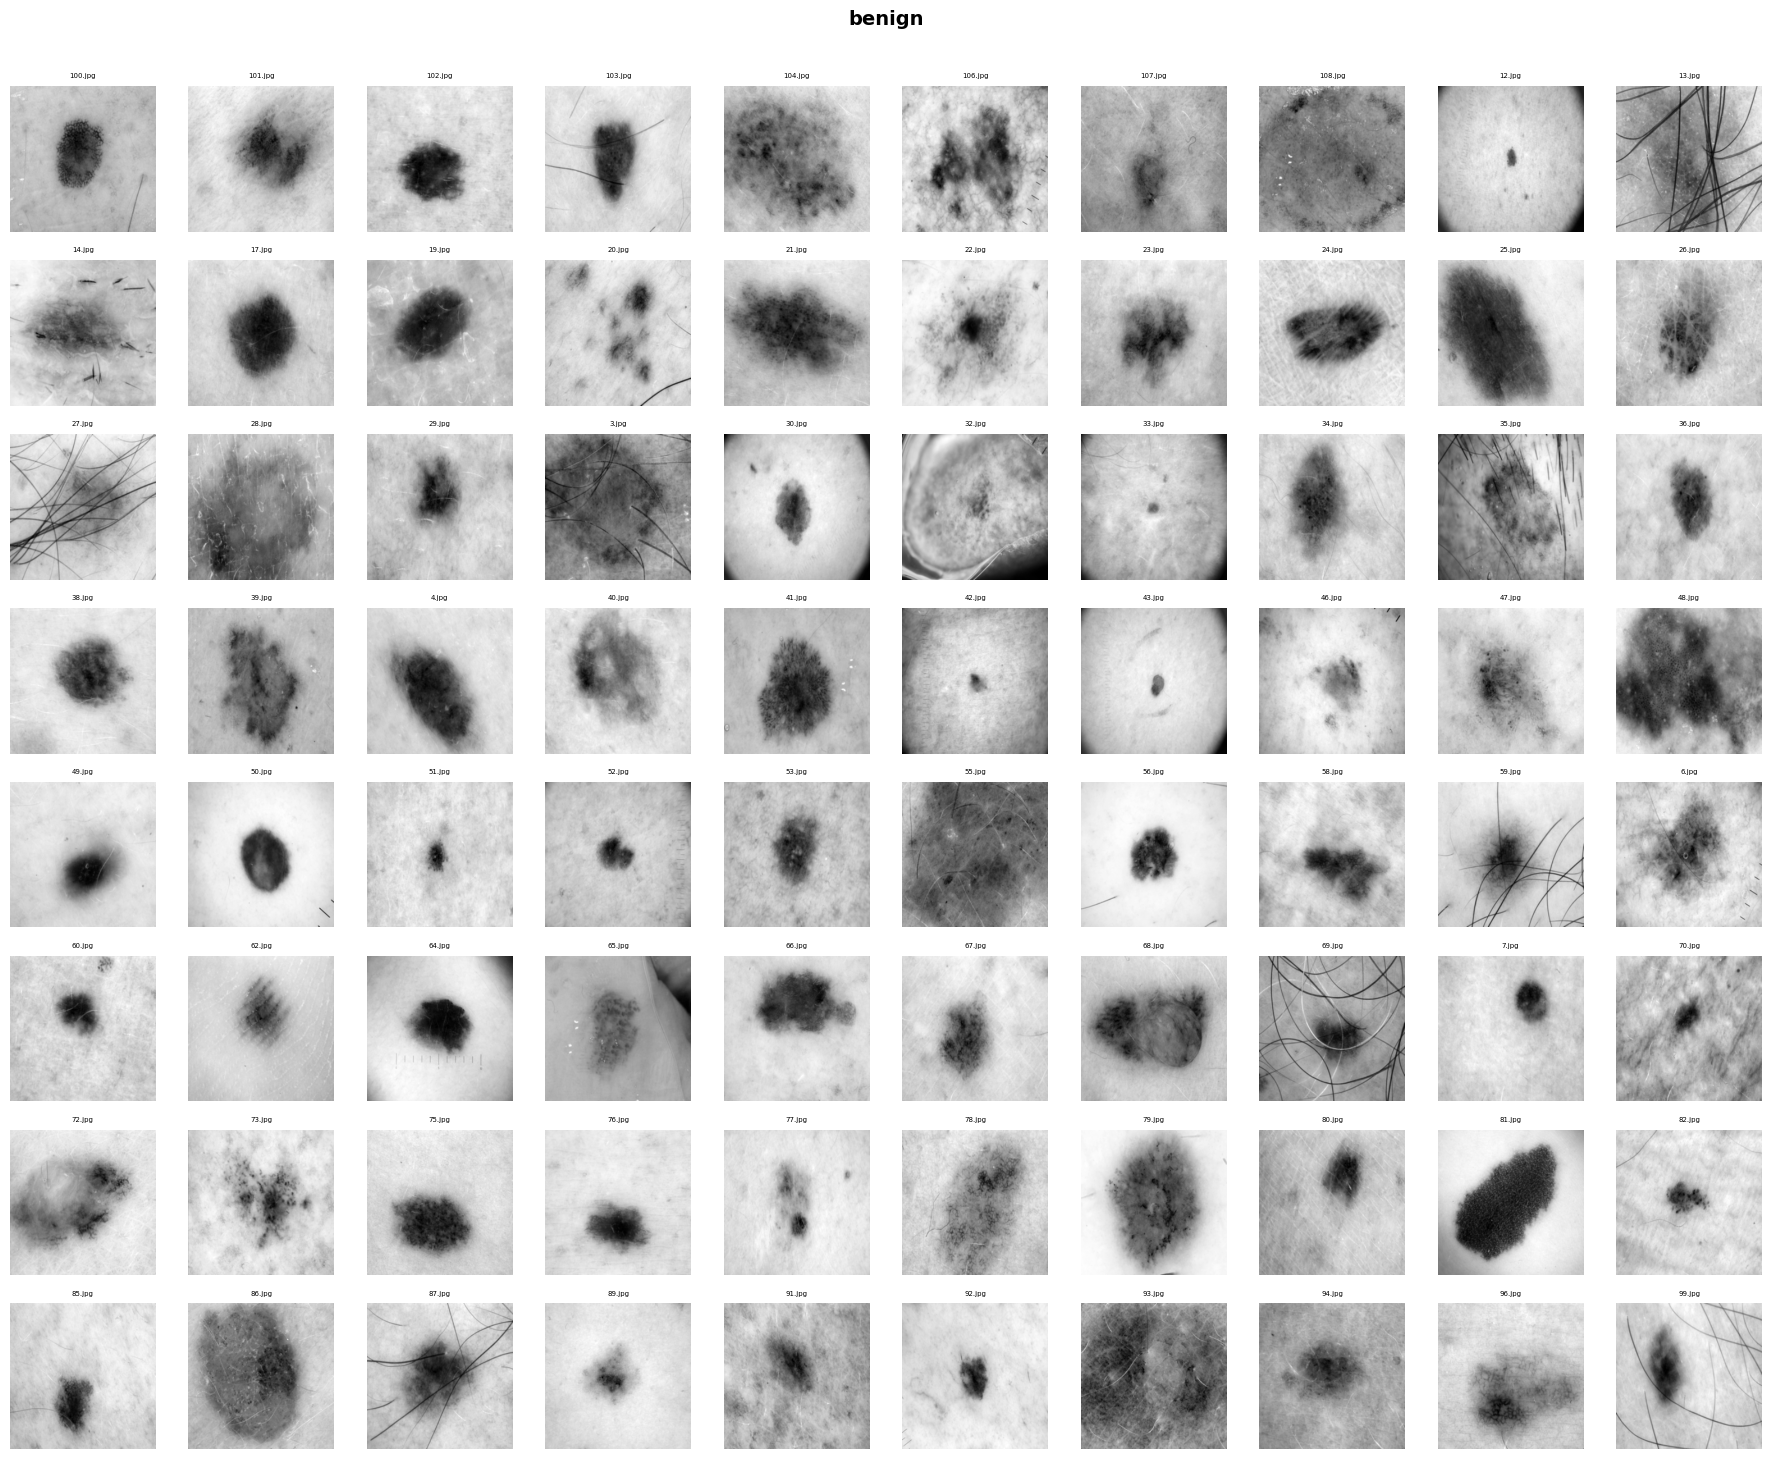

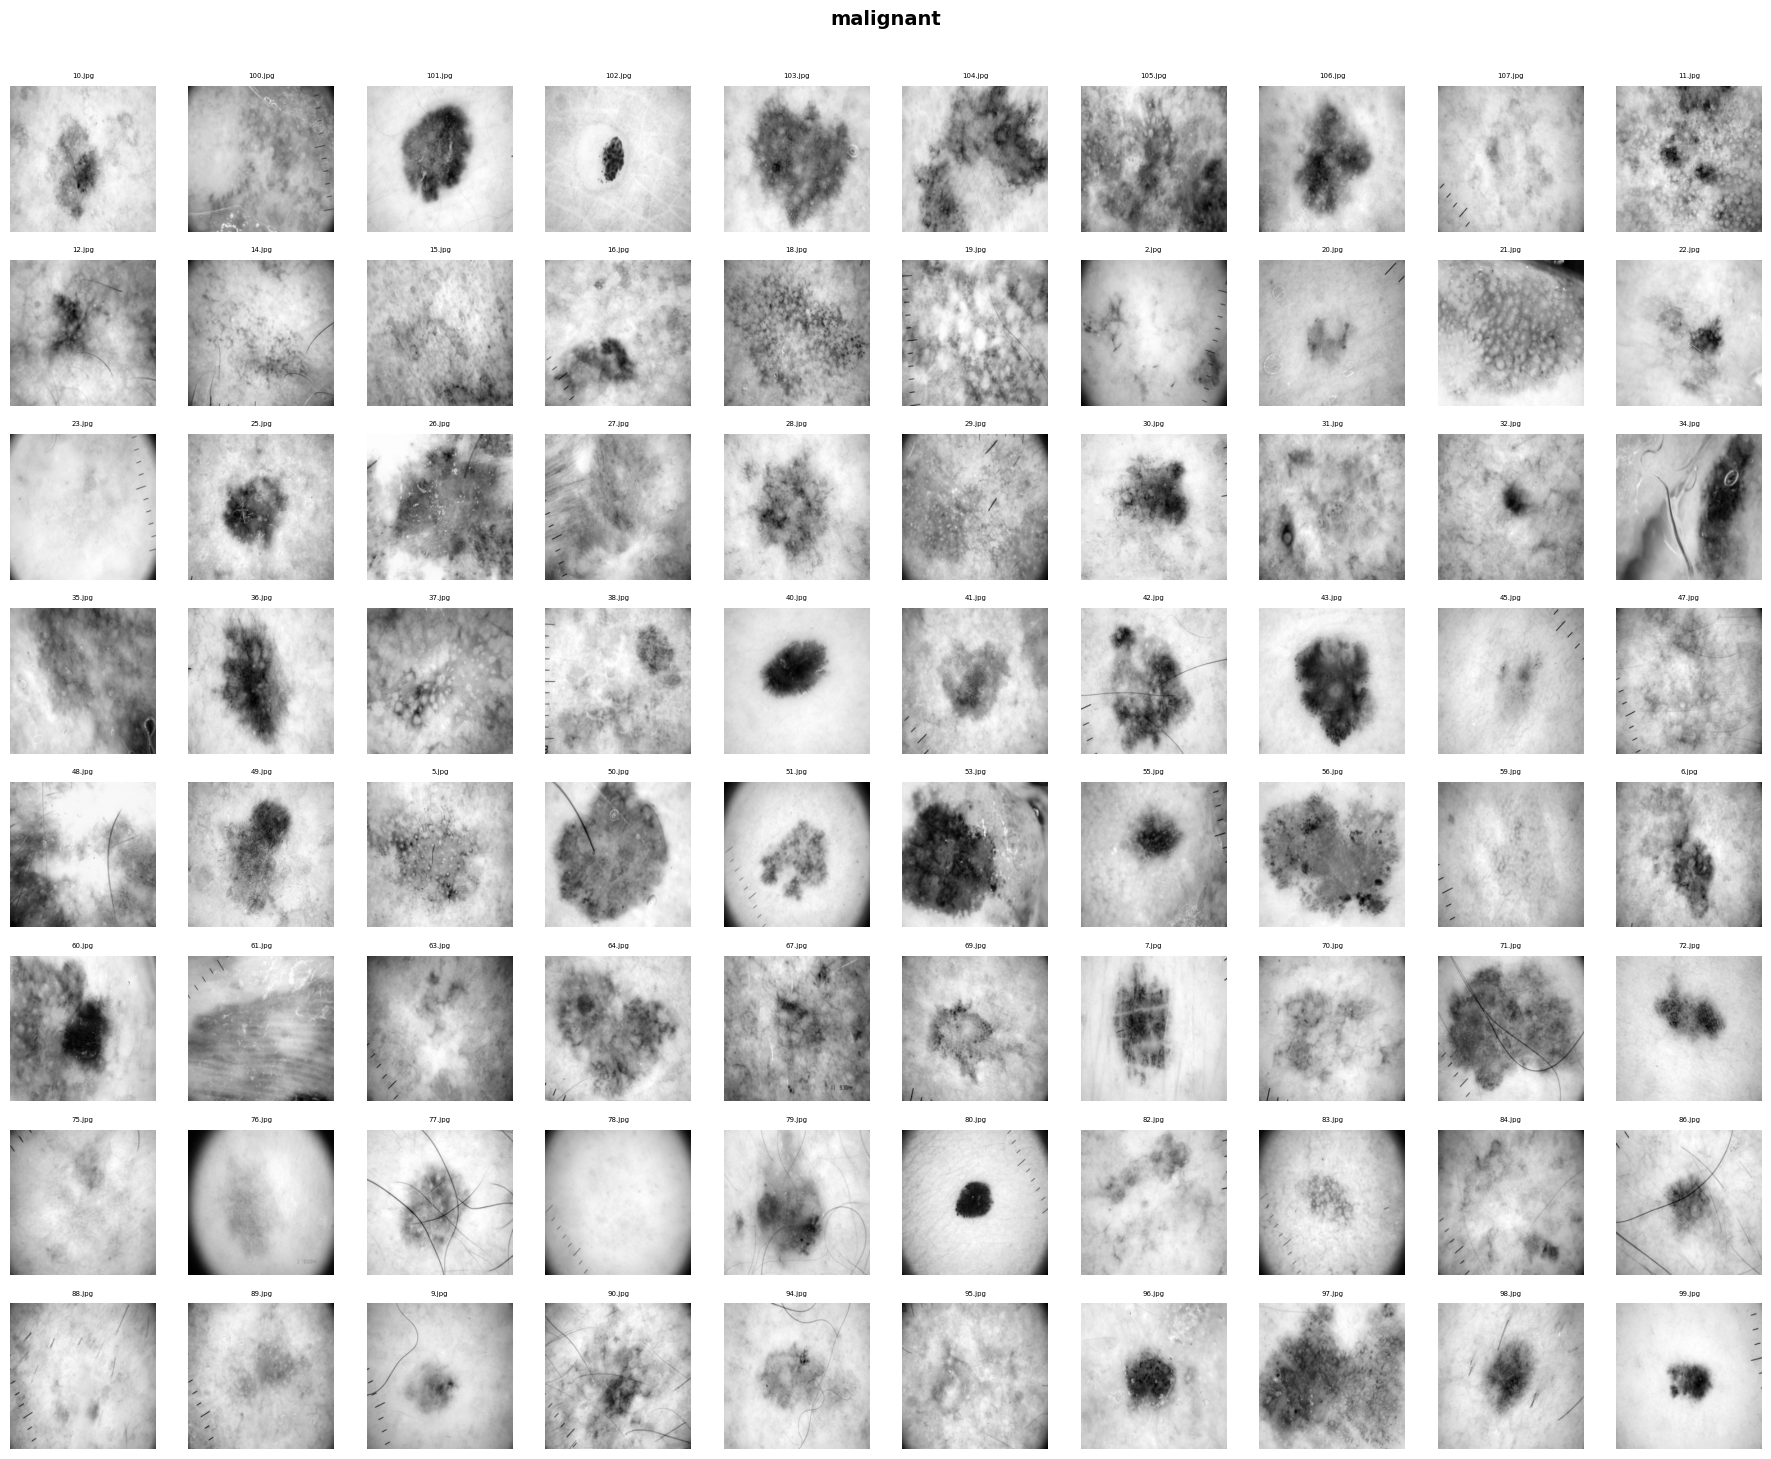

In [5]:
def plot_grid(gray_images, filenames, label, cols=10):
    """Menampilkan semua gambar grayscale dalam grid."""
    n = len(gray_images)
    if n == 0:
        print(f"Tidak ada gambar untuk label: {label}")
        return
        
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.8, rows * 1.8))
    fig.suptitle(f'{label}', fontsize=14, fontweight='bold', y=1.01)

    axes_flat = axes.flatten()
    for i, ax in enumerate(axes_flat):
        if i < n:
            ax.imshow(gray_images[i], cmap='gray')
            ax.set_title(filenames[i], fontsize=5)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

unique_labels = sorted(set(labels))  

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]
    
    images_label = [data[idx] for idx in idxs]
    filenames_label = [file_name[idx] for idx in idxs]
    plot_grid(images_label, filenames_label, label, cols=10)

## Preprocessing

Kode dibawah melakukan proses pra-pemrosesan citra secara berurutan dan memvisualisasikan hasilnya ke dalam bentuk grid berdasarkan label kelas masing-masing. Fungsi percobaan3 menerima sebuah citra, kemudian melakukan segmentasi biner otomatis menggunakan metode Otsu's Thresholding dan inversi biner (cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU), dilanjutkan dengan operasi morfologi opening dan closing secara berurutan untuk membersihkan objek, lalu mengembalikan hasilnya. Seluruh dataset data kemudian diproses secara langsung menggunakan list comprehension hingga menghasilkan list baru bernama dataPreprocessed. Selanjutnya, kode melakukan iterasi untuk setiap kelas unik di dalam labels guna menyaring indeks gambar yang sesuai. Untuk setiap label tersebut, dibuat sebuah grid visualisasi berukuran 8 x 10(80 plot) untuk menampilkan citra hasil pemrosesan dalam format grayscale tanpa sumbu koordinat, di mana tata letak dan judul disesuaikan agar rapi dan tidak saling tumpang tindi

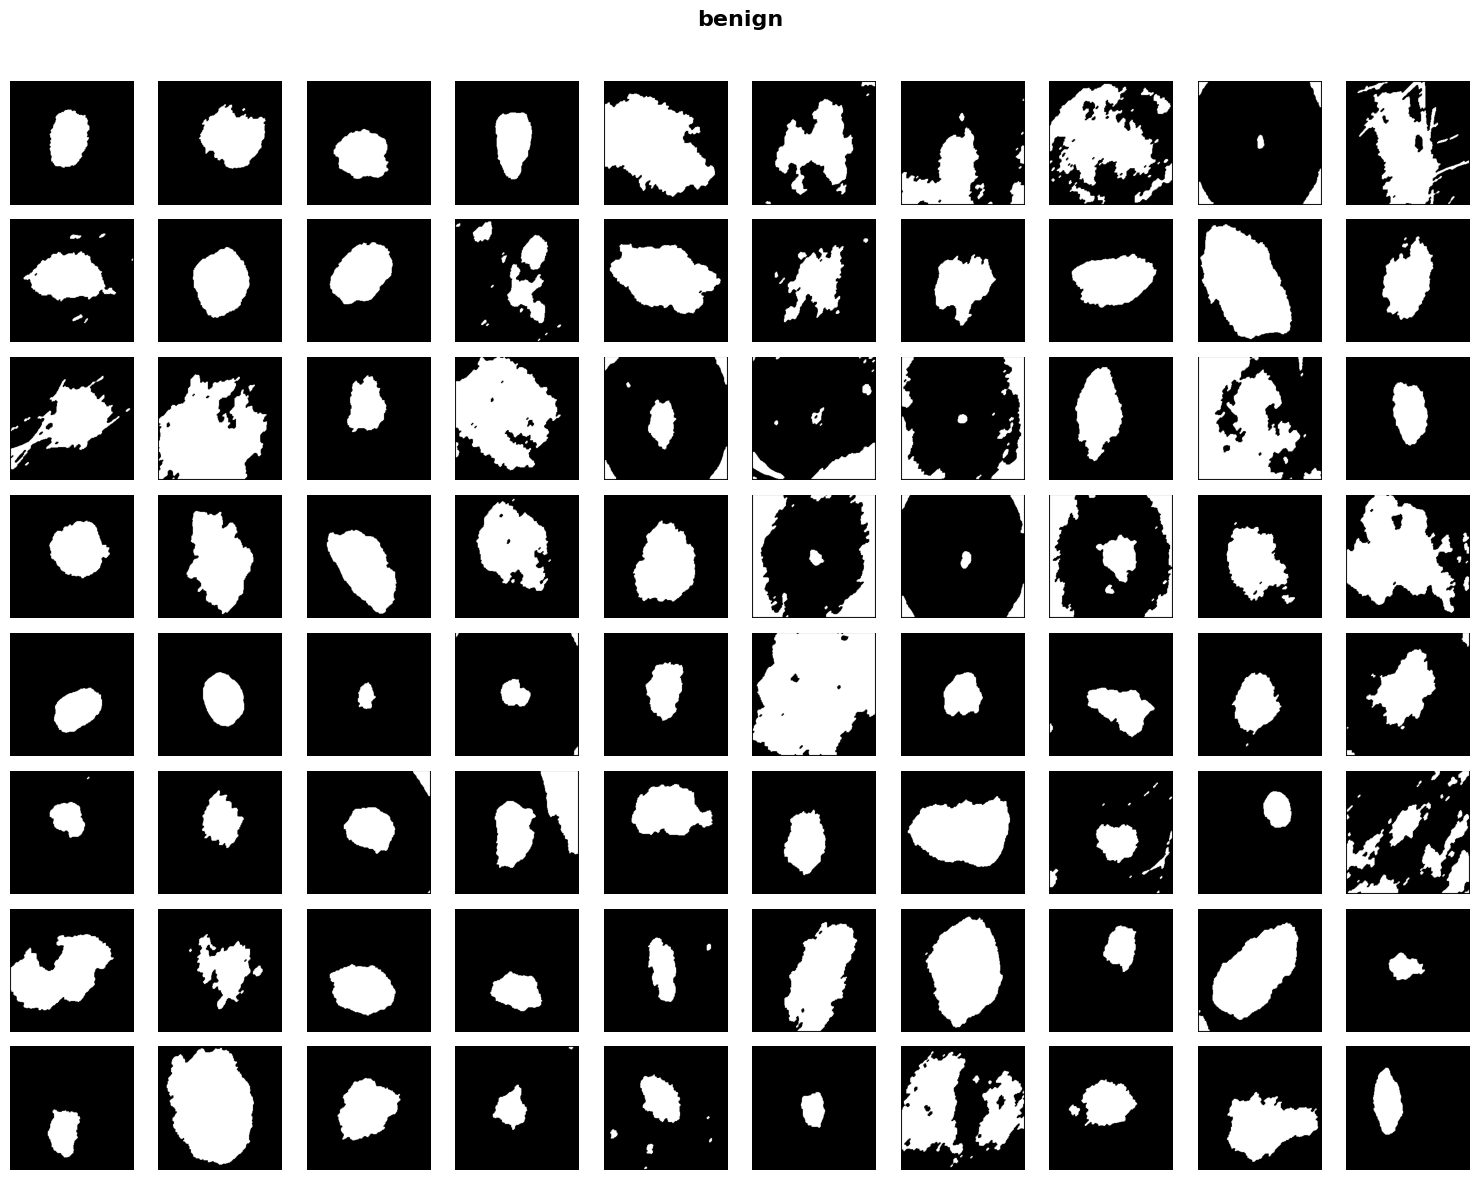

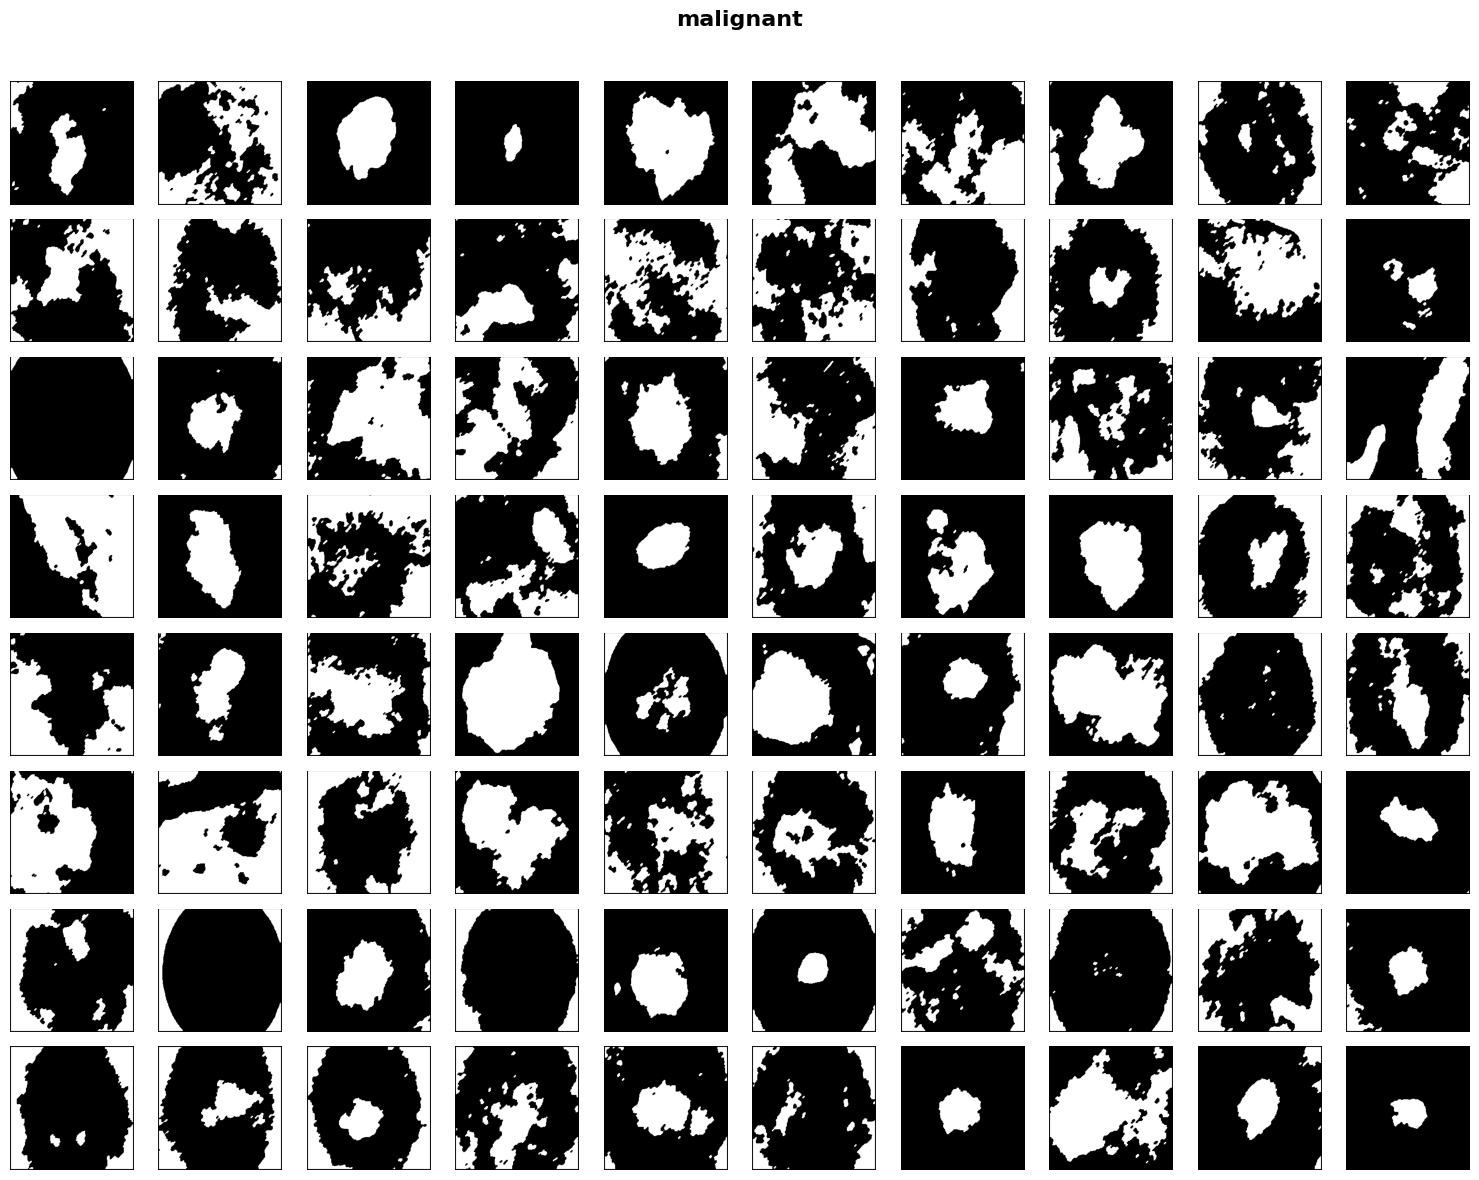

In [6]:
def percobaan3(img):
    _, img_tresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    img_opening = opening(img_tresh, kernel)
    img_closing = closing(img_opening, kernel)
    return img_closing

# 2. Proses langsung seluruh gambar
dataPreprocessed = [percobaan3(img) for img in data]
unique_labels = sorted(set(labels))

for label in unique_labels:
    # Ambil semua indeks gambar dari label ini
    idxs = [j for j, l in enumerate(labels) if l == label]
    
    cols = 10
    rows = 8
    
    fig, axs = plt.subplots(rows, cols, figsize=(15, 12))  # Ukuran figsize disesuaikan agar tidak tumpang tindih
    fig.suptitle(f'{label}', fontsize=16, fontweight='bold')
    
    # Ratakan array axes agar mudah diakses menggunakan single loop k
    axs_flat = axs.flatten()
    
    # PERBAIKAN 2: Lakukan perulangan sebanyak jumlah gambar (80 gambar)
    for k in range(len(idxs)):
        if k < len(axs_flat):  # Jaga-jaga agar tidak melebihi batas ukuran grid
            ax = axs_flat[k]
            
            # Menampilkan gambar hasil proses berdasarkan indeks yang cocok
            ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')
            ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.92) 
    plt.show()

## Ekstraksi Fitur

In [7]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")
    
    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    
    return glcm

Fungsi glcm dibuat untuk mengekstraksi matriks korelasi spasial piksel (Gray-Level Co-occurrence Matrix) dari suatu citra berdasarkan sudut orientasi yang spesifik. Fungsi ini memproses dua argumen input, yaitu image berupa citra biner atau skala abu-abu dan derajat yang menentukan arah analisis tetangga piksel (pilihannya meliputi 0, 45, 90, atau 135 derajat). Di awal proses, program melakukan validasi nilai sudut menggunakan struktur percabangan untuk mengubah satuan derajat menjadi bentuk radian seperti 0, np.pi / 4, np.pi / 2, atau 3 * np.pi / 4 yang dibutuhkan oleh algoritma pemroses. Jika parameter sudut yang dimasukkan di luar ketentuan tersebut, sistem secara otomatis memicu pesan kesalahan ValueError. Langkah terakhir dari fungsi ini adalah mengeksekusi perintah graycomatrix dari modul scikit-image untuk mengonstruksi matriks GLCM dengan konfigurasi jarak piksel bernilai 1, resolusi tingkat keabuan sebesar 256, serta mengaktifkan opsi symmetric=True agar matriks berpasangan secara bolak-balik dan normed=True untuk mengubah nilai kemunculan piksel menjadi skala probabilitas.

In [8]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

kode di atas digunakan untuk mengambil metrik statistik dari matriks GLCM guna kebutuhan analisis tekstur citra. Menggunakan fungsi graycoprops dari library scikit-image, kode ini mengekstraksi enam fitur bawaan yaitu correlation, dissimilarity, homogeneity, contrast, ASM, dan energy, lalu langsung mengakses elemen array pada indeks [0, 0] agar menghasilkan nilai skalar. Selain itu, fungsi entropyGlcm ditambahkan secara terpisah untuk menghitung derajat keacakan struktur tekstur dengan cara meratakan matriks input menjadi array satu dimensi (.ravel()) sebelum memprosesnya lewat fungsi entropi.

Kode tersebut melakukan proses ekstraksi fitur tekstur berbasis Gray-Level Co-occurrence Matrix (GLCM) dari kumpulan citra yang telah melewati tahap pra-pemrosesan, kemudian menyusun hasilnya ke dalam sebuah DataFrame. Fungsi ekstrak_fitur_glcm menerima dua parameter input, yaitu data yang berisi daftar citra dan nama_prepro sebagai penanda nama metode pra-pemrosesan yang digunakan. Di dalam fungsi ini, sebuah list kosong bernama fitur_list disiapkan untuk menampung hasil perhitungan. Melalui perulangan (looping), setiap citra di dalam dataset dipastikan bertipe data np.uint8 sebelum dihitung matriks GLCM-nya pada orientasi sudut 0 derajat menggunakan fungsi glcm.
Dari matriks GLCM yang terbentuk, fungsi ini mengekstraksi tujuh fitur statistik statistik orde kedua, yaitu contrast, correlation, energy, homogeneity, dissimilarity, ASM, dan entropy, yang semuanya disimpan ke dalam struktur data dictionary. Setelah seluruh gambar selesai diproses dan dimasukkan ke dalam fitur_list, data tersebut dikonversi menjadi sebuah objek DataFrame menggunakan pustaka Pandas. Sebuah kolom baru bernama tahap ditambahkan untuk mencatat label nama pra-pemrosesan dari citra tersebut. Pada bagian akhir, fungsi ini dipanggil dengan memasukkan variabel dataPreprocessed dan string 'percobaan3', lalu hasilnya disimpan ke dalam variabel df2 sebelum akhirnya ditampilkan ke layar menggunakan perintah display.

In [9]:
# Fungsi ekstraksi fitur untuk list citra
def ekstrak_fitur_glcm(data, nama_prepro):
    fitur_list = []
    for img in data:
        img_u8 = img.astype(np.uint8)
        m = glcm(img_u8, 0)  # derajat 0
        
        fitur = {
            'contrast': contrast(m),
            'correlation': correlation(m),
            'energy': energy(m),
            'homogeneity': homogenity(m),
            'dissimilarity': dissimilarity(m),
            'ASM': ASM(m),
            'entropy': entropyGlcm(m)
        }
        fitur_list.append(fitur)

    df = pd.DataFrame(fitur_list)
    df['tahap'] = nama_prepro
    return df

df2 = ekstrak_fitur_glcm(dataPreprocessed, 'percobaan3')
display(df2)

,contrast,correlation,energy,homogeneity,dissimilarity,ASM,entropy,tahap
0,245.039063,0.981589,0.889702,0.996232,0.960938,0.791569,0.381434,percobaan3
1,346.640625,0.982023,0.835556,0.994669,1.359375,0.698155,0.504801,percobaan3
2,219.140625,0.985273,0.876244,0.996630,0.859375,0.767804,0.410994,percobaan3
3,280.898438,0.979692,0.884860,0.995680,1.101562,0.782978,0.394888,percobaan3
4,653.437500,0.979870,0.700599,0.989951,2.562500,0.490839,0.748579,percobaan3
...,...,...,...,...,...,...,...,...
155,1322.812500,0.930600,0.828820,0.979657,5.187500,0.686943,0.562726,percobaan3
156,215.156250,0.979302,0.914788,0.996691,0.843750,0.836838,0.317269,percobaan3
157,1259.062500,0.961259,0.693697,0.980638,4.937500,0.481215,0.788489,percobaan3
158,521.953125,0.965108,0.872917,0.991973,2.046875,0.761983,0.434895,percobaan3


In [10]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

for i in range(len(data)):  
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

Menginisialisasi empat list kosong, yaitu Derajat0, Derajat45, Derajat90, dan Derajat135. Dalam loop pertama, untuk setiap citra dalam dataPreprocessed, fungsi glcm dipanggil empat kali untuk menghitung matriks GLCM pada sudut 0, 45, 90, dan 135 derajat, lalu hasilnya masing-masing ditambahkan ke list Derajat0 hingga Derajat135. Setelah matriks GLCM untuk semua sudut selesai dihitung, kode menginisialisasi berbagai list kosong lainnya untuk menyimpan properti tekstur yang diekstraksi, seperti Kontras0 hingga Kontras135, dissimilarity0 hingga dissimilarity135, dan seterusnya untuk fitur homogenitas, entropi, ASM, energi, serta korelasi pada setiap orientasi sudut. Kemudian, serangkaian loop terpisah dieksekusi secara berurutan. Setiap loop ini mengiterasi seluruh dataset, di mana untuk setiap citra, kode memanggil fungsi ekstraksi properti GLCM yang spesifik (seperti correlation, contrast, dissimilarity, homogenity, entropyGlcm, ASM, dan energy) pada matriks GLCM yang sesuai untuk keempat sudut tersebut. Hasil dari setiap perhitungan properti kemudian ditambahkan ke dalam list fitur yang relevan, seperti memasukkan nilai kontras sudut 0 derajat ke dalam Kontras0.

## Hasil Ekstraksi ke CSV

In [11]:
features = []
for i in range(len(dataPreprocessed)):
    fitur = [
        contrast(Derajat0[i]), contrast(Derajat45[i]), contrast(Derajat90[i]), contrast(Derajat135[i]),
        dissimilarity(Derajat0[i]), dissimilarity(Derajat45[i]), dissimilarity(Derajat90[i]), dissimilarity(Derajat135[i]),
        homogenity(Derajat0[i]), homogenity(Derajat45[i]), homogenity(Derajat90[i]), homogenity(Derajat135[i]),
        entropyGlcm(Derajat0[i]), entropyGlcm(Derajat45[i]), entropyGlcm(Derajat90[i]), entropyGlcm(Derajat135[i]),
        ASM(Derajat0[i]), ASM(Derajat45[i]), ASM(Derajat90[i]), ASM(Derajat135[i]),
        energy(Derajat0[i]), energy(Derajat45[i]), energy(Derajat90[i]), energy(Derajat135[i]),
        correlation(Derajat0[i]), correlation(Derajat45[i]), correlation(Derajat90[i]), correlation(Derajat135[i]),
    ]
    features.append(fitur)

columns = [
    "contrast_0", "contrast_45", "contrast_90", "contrast_135",
    "dissimilarity_0", "dissimilarity_45", "dissimilarity_90", "dissimilarity_135",
    "homogeneity_0", "homogeneity_45", "homogeneity_90", "homogeneity_135",
    "entropy_0", "entropy_45", "entropy_90", "entropy_135",
    "ASM_0", "ASM_45", "ASM_90", "ASM_135",
    "energy_0", "energy_45", "energy_90", "energy_135",
    "correlation_0", "correlation_45", "correlation_90", "correlation_135"
]
df_fitur = pd.DataFrame(features, columns=columns)

Menginisialisasi sebuah list kosong bernama features yang berfungsi sebagai wadah utama untuk menyatukan seluruh komponen fitur hasil ekstraksi. Kemudian, kode ini melakukan iterasi untuk setiap citra dalam dataPreprocessed guna mengumpulkan nilai properti dari berbagai sudut pandang orientasi. Dalam setiap tahap perulangan, sebuah sub-list dibangun dengan memasukkan secara berurutan nilai dari fitur kontras, ketidakmiripan, homogenitas, entropi, ASM, energi, dan korelasi, di mana masing-masing fitur tersebut mencakup hasil perhitungan dari keempat sudut GLCM (0, 45, 90, dan 135 derajat) yang telah disimpan sebelumnya di dalam variabel Derajat0 hingga Derajat135. Sub-list yang telah terisi lengkap ini kemudian dimasukkan ke dalam list utama features. Setelah proses perulangan selesai untuk seluruh citra, sebuah list bernama columns didefinisikan secara eksplisit untuk menampung nama-nama kolom yang representatif, seperti "contrast_0" atau "dissimilarity_45", guna menandai jenis properti beserta sudutnya. Akhirnya, objek features tersebut dikonversi menjadi sebuah DataFrame Pandas bernama df_fitur menggunakan perintah pd.DataFrame(), dengan menerapkan susunan tabel yang label kolomnya mengacu pada daftar nama di dalam list columns.

Menginisialisasi sebuah kamus (dictionary) bernama dataTable yang berfungsi untuk memetakan nama-nama kolom tabel ke list data yang bersesuaian. Di dalam kamus ini, kolom identitas seperti 'Filename' dan 'Label' dipasangkan dengan file_name dan labels, sementara kolom properti fitur (seperti 'Contrast0', 'Homogeneity0', dan seterusnya untuk seluruh kombinasi fitur serta sudut) dipetakan ke list nilai hasil ekstraksi yang telah dihitung pada tahap sebelumnya. Setelah struktur dataTable selesai dibangun, kode ini mengonversinya menjadi sebuah objek DataFrame Pandas bernama df menggunakan perintah pd.DataFrame(dataTable) untuk menyatukan seluruh informasi ke dalam format tabel yang terstruktur. Selanjutnya, DataFrame df tersebut diekspor menjadi file dokumen CSV dengan nama hasil_ekstraksi_percobaan1.csv menggunakan metode df.to_csv(), di mana parameter index=False diterapkan agar nomor indeks baris tidak ikut tersimpan sebagai kolom baru. Sebagai tahap penutup, kode ini memuat kembali file CSV yang telah tersimpan ke dalam memori sebagai DataFrame baru bernama hasilEkstrak lewat fungsi pd.read_csv(), lalu menampilkannya ke layar.

In [12]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan3.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan3.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,100.jpg,benign,245.039063,370.0,197.226563,310.0,0.996232,0.994310,0.996967,0.995233,...,0.792300,0.789882,0.889702,0.888239,0.890112,0.888753,0.981589,0.972294,0.985181,0.976787
1,101.jpg,benign,346.640625,566.0,318.750000,456.0,0.994669,0.991296,0.995098,0.992987,...,0.698579,0.695589,0.835556,0.833021,0.835810,0.834020,0.982023,0.970737,0.983470,0.976424
2,102.jpg,benign,219.140625,348.0,249.023438,352.0,0.996630,0.994648,0.996170,0.994587,...,0.767348,0.765018,0.876244,0.874688,0.875984,0.874653,0.985273,0.976691,0.983265,0.976423
3,103.jpg,benign,280.898438,354.0,155.390625,336.0,0.995680,0.994556,0.997610,0.994833,...,0.784895,0.781420,0.884860,0.883825,0.885943,0.883979,0.979692,0.974494,0.988766,0.975791
4,104.jpg,benign,653.437500,982.0,585.703125,1000.0,0.989951,0.984898,0.990993,0.984622,...,0.491861,0.485503,0.700599,0.696973,0.701328,0.696780,0.979870,0.969757,0.981957,0.969203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,95.jpg,malignant,1322.812500,1972.0,940.312500,1766.0,0.979657,0.969674,0.985539,0.972842,...,0.692620,0.679552,0.828820,0.822536,0.832238,0.824349,0.930600,0.896857,0.950667,0.907632
156,96.jpg,malignant,215.156250,310.0,193.242188,300.0,0.996691,0.995233,0.997028,0.995386,...,0.837173,0.834977,0.914788,0.913687,0.914971,0.913771,0.979302,0.970284,0.981410,0.971242
157,97.jpg,malignant,1259.062500,2008.0,1103.671875,1672.0,0.980638,0.969120,0.983027,0.974287,...,0.483518,0.475081,0.693697,0.685716,0.695355,0.689261,0.961259,0.938223,0.966040,0.948560
158,98.jpg,malignant,521.953125,818.0,390.468750,610.0,0.991973,0.987420,0.993995,0.990619,...,0.763977,0.759889,0.872917,0.869920,0.874058,0.871716,0.965108,0.945499,0.973898,0.959358


## Feature Selection

### Correlation

Kode dibawah digunakan untuk analisis data dengan menghitung korelasi antar fitur dan melakukan seleksi fitur berdasarkan nilai korelasi. Pertama, kolom non-numerik seperti 'Label' dan 'Filename' dihilangkan dari DataFrame hasilEkstrak, kemudian metode .corr() dipanggil untuk menghitung matriks korelasi antar semua fitur yang tersisa, di mana hasilnya disimpan dalam variabel correlation. Selanjutnya, kode ini melakukan seleksi fitur untuk mengurangi redundansi dengan mengidentifikasi fitur-fitur yang memiliki hubungan sangat kuat satu sama lain. Sebuah threshold (ambang batas) ditetapkan sebesar 1.00 untuk menentukan batas nilai korelasi yang dianggap redundan, dan sebuah array boolean bernama columns diinisialisasi dengan nilai True untuk seluruh fitur yang ada. Kemudian, dua loop bersarang digunakan untuk mengiterasi setiap elemen di dalam matriks correlation. Jika ditemukan sepasang fitur (i dan j) yang memiliki nilai korelasi lebih besar atau sama dengan threshold, dan fitur j saat itu masih bernilai True, maka posisi fitur j di dalam array columns akan diubah menjadi False sebagai tanda bahwa fitur tersebut dieliminasi.Setelah proses perulangan selesai, sebuah list bernama select dibuat untuk menampung nama-nama kolom fitur yang masih bertahan dengan status True di dalam array columns. Berdasarkan daftar nama tersebut, DataFrame baru bernama x_new dibentuk dari hasilEkstrak dengan hanya menyertakan fitur-fitur yang lolos seleksi. Secara terpisah, kolom target untuk kebutuhan pemodelan disimpan ke dalam variabel y dengan mengambil data dari kolom 'Label'. Terakhir, untuk mengevaluasi sekaligus memvisualisasikan korelasi antar-fitur yang tersisa setelah penyaringan, sebuah grafik peta panas ditampilkan menggunakan fungsi sns.heatmap(). Ukuran kanvas visualisasi diatur sebesar 17 X 17 inci menggunakan plt.figure(), dengan menggunakan data matriks korelasi terbaru dari x_new.corr(), serta dilengkapi parameter annot=True untuk memunculkan angka korelasi, cmap='Blues' untuk gradasi warna biru, dan fmt=".2f" untuk menampilkan nilai numerik dalam format dua angka di belakang koma.

<Axes: >

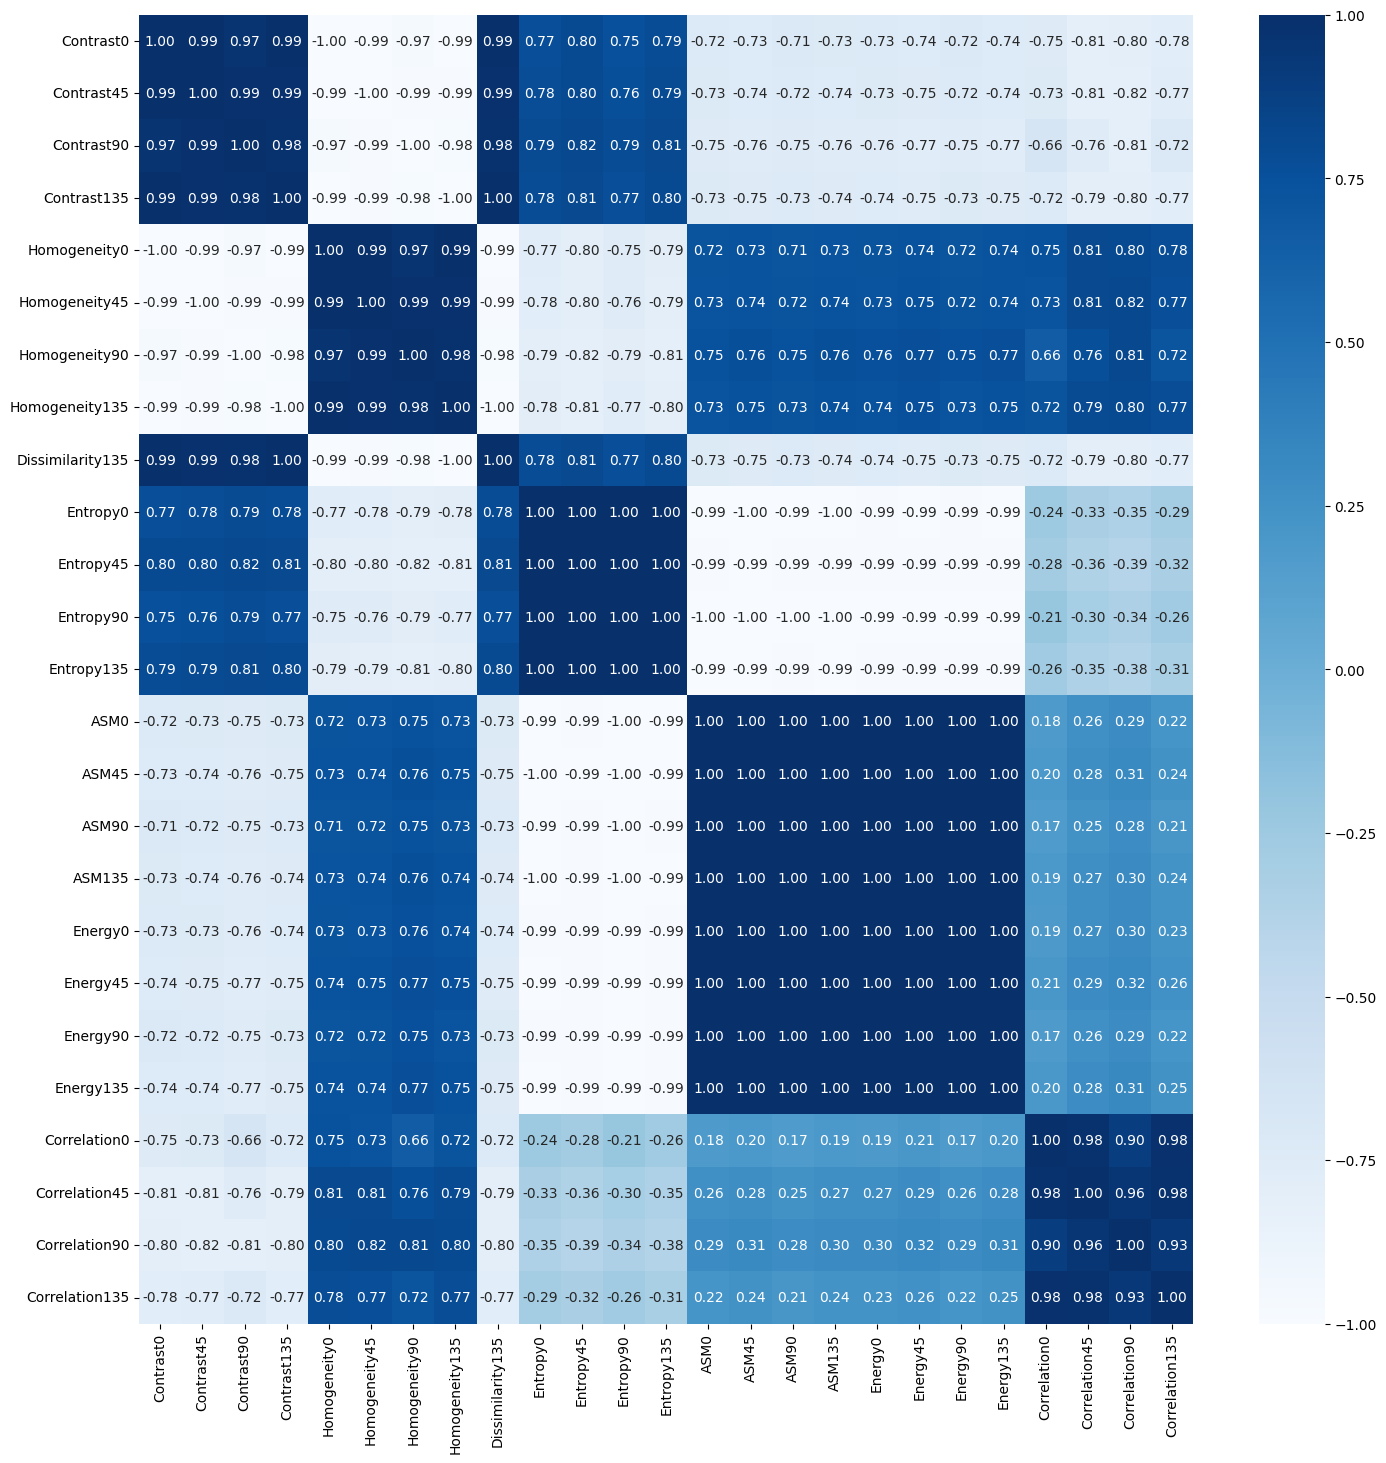

In [13]:
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 1.00 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

## Splitting Data

Kode ini digunakan untuk membagi dataset menjadi dua bagian terpisah, yaitu data train dan data Test, sebelum dimasukkan ke dalam model pembelajaran mesin. Pertama, fungsi train_test_split dari pustaka Scikit-Learn dipanggil dengan menerima dua input utama: x_new yang berisi kumpulan fitur hasil seleksi sebelumnya, dan y yang bertindak sebagai label target. Parameter test_size=0.2 ditentukan untuk mengalokasikan 20 dari total keseluruhan data sebagai data uji, sementara 80 sisanya secara otomatis dialokasikan sebagai data latih untuk melatih model. Selain itu, parameter random_state=42 disematkan guna mengunci pola pengacakan data, sehingga pembagian data tetap konsisten dan menghasilkan subset yang sama setiap kali kode ini dijalankan ulang

In [14]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(128, 25)
(32, 25)


## Feature Normalization

In [15]:
# normalisasi mean std (Standardization / Z-score normalization)
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

Kode di atas melakukan normalisasi Z-score pada data training (X_train) dan testing (X_test) dengan mengurangi setiap nilai fitur dengan rata-rata dan membaginya dengan standar deviasi. Yang penting, rata-rata dan standar deviasi hanya dihitung dari X_train, lalu diterapkan ke X_test — praktik ini mencegah data leakage dan memastikan model diuji secara objektif tanpa informasi dari data testing bocor ke proses pelatihan.

## Modeling

### Define Model

In [16]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

Fungsi `generateClassificationReport()` didefinisikan untuk mencetak laporan klasifikasi lengkap, confusion matrix, dan akurasi model. Kemudian tiga model klasifikasi diinisialisasi, yaitu `RandomForestClassifier` dengan 5 estimator, `SVC` dengan kernel RBF, dan `KNeighborsClassifier` dengan 5 tetangga terdekat.

### Train Random Forest Classifier

Kode ini digunakan untuk melatih model Random Forest Classifier (rf) menggunakan dataset yang tersedia, kemudian melakukan prediksi sekaligus mengevaluasi performanya pada subset data latih (training set) dan data uji (testing set). Pertama, perintah rf.fit(X_train, y_train) dieksekusi untuk melatih algoritma Random Forest agar dapat mengenali pola hubungan antara fitur ekstraksi pada X_train dengan label target di y_train.

Setelah model selesai dilatih, proses evaluasi pertama dilakukan terhadap data latih. Kode mencetak penanda "------Training Set------", lalu menggunakan fungsi rf.predict(X_train) untuk menghasilkan vektor prediksi y_pred. Hasil prediksi tersebut kemudian dimasukkan ke dalam fungsi generateClassificationReport(y_train, y_pred) yang telah dibuat sebelumnya untuk menampilkan metrik evaluasi detail seperti laporan klasifikasi, confusion matrix, dan skor akurasi pada data latih. Selanjutnya, prosedur yang sama diterapkan untuk menguji performa model pada data baru yang belum pernah dilihat sebelumnya (testing set). Kode mencetak penanda "\n------Testing Set------", memprediksi label untuk subset X_test, dan mengevaluasi hasilnya dengan memanggil fungsi generateClassificationReport(y_test, y_pred) guna mengukur seberapa baik kemampuan generalisasi model terhadap data uji.

In [17]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

      benign       0.95      0.95      0.95        64
   malignant       0.95      0.95      0.95        64

    accuracy                           0.95       128
   macro avg       0.95      0.95      0.95       128
weighted avg       0.95      0.95      0.95       128

[[61  3]
 [ 3 61]]
Accuracy: 0.953125

------Testing Set------
              precision    recall  f1-score   support

      benign       0.87      0.81      0.84        16
   malignant       0.82      0.88      0.85        16

    accuracy                           0.84        32
   macro avg       0.85      0.84      0.84        32
weighted avg       0.85      0.84      0.84        32

[[13  3]
 [ 2 14]]
Accuracy: 0.84375


### Train SVM Classifier

Kode ini digunakan untuk melatih model Support Vector Machine (svm) menggunakan dataset yang tersedia, kemudian melakukan prediksi sekaligus mengevaluasi performanya pada subset data latih (training set) dan data uji (testing set). Pertama, perintah svm.fit(X_train, y_train) dieksekusi untuk melatih algoritma SVM agar dapat menemukan hyperplane pembatas optimal yang memisahkan kelas-kelas data berdasarkan fitur pada X_train dan label target di y_train.

Setelah proses pelatihan selesai, tahap evaluasi pertama dilakukan terhadap data latih itu sendiri. Kode mencetak penanda "------Training Set------", lalu memanggil fungsi svm.predict(X_train) untuk menghasilkan vektor prediksi y_pred. Hasil prediksi ini kemudian dimasukkan ke dalam fungsi generateClassificationReport(y_train, y_pred) untuk menampilkan laporan klasifikasi detail, confusion matrix, dan skor akurasi guna melihat seberapa baik model mengenali data yang sudah dipelajari. Selanjutnya, prosedur serupa diterapkan untuk menguji kemampuan generalisasi model pada data baru yang belum pernah dilihat sebelumnya (testing set). Kode mencetak penanda "\n------Testing Set------", melakukan prediksi terhadap subset X_test, dan mengevaluasi hasilnya dengan memanggil fungsi generateClassificationReport(y_test, y_pred) guna mengukur performa riil model dalam mengklasifikasikan data uji.

In [18]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

      benign       0.73      0.83      0.77        64
   malignant       0.80      0.69      0.74        64

    accuracy                           0.76       128
   macro avg       0.76      0.76      0.76       128
weighted avg       0.76      0.76      0.76       128

[[53 11]
 [20 44]]
Accuracy: 0.7578125

------Testing Set------
              precision    recall  f1-score   support

      benign       0.71      0.94      0.81        16
   malignant       0.91      0.62      0.74        16

    accuracy                           0.78        32
   macro avg       0.81      0.78      0.78        32
weighted avg       0.81      0.78      0.78        32

[[15  1]
 [ 6 10]]
Accuracy: 0.78125


### Train KNN Classifier

Kode ini digunakan untuk melatih model K-Neighbors Classifier (knn) menggunakan dataset yang tersedia, kemudian melakukan prediksi sekaligus mengevaluasi performanya pada subset data latih (training set) dan data uji (testing set). Pertama, perintah knn.fit(X_train, y_train) dieksekusi untuk membangun model KNN, di mana algoritma akan menyimpan seluruh titik data dari fitur X_train beserta label targetnya di y_train sebagai acuan dalam menentukan jarak tetangga terdekat.

Setelah model siap, tahap evaluasi pertama dilakukan terhadap data latih itu sendiri. Kode mencetak penanda "------Training Set------", lalu memanggil fungsi knn.predict(X_train) untuk menghasilkan vektor prediksi y_pred. Hasil prediksi ini kemudian dimasukkan ke dalam fungsi generateClassificationReport(y_train, y_pred) untuk menampilkan laporan klasifikasi detail, confusion matrix, dan skor akurasi guna melihat tingkat ketepatan model dalam mengklasifikasikan data yang sudah disimpan. Selanjutnya, prosedur serupa diterapkan untuk menguji kemampuan generalisasi model pada data baru yang belum pernah dilihat sebelumnya (testing set). Kode mencetak penanda "\n------Testing Set------", melakukan prediksi terhadap subset X_test, dan mengevaluasi hasilnya dengan memanggil fungsi generateClassificationReport(y_test, y_pred) guna mengukur performa riil model KNN dalam mengklasifikasikan data uji.

In [19]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

      benign       0.78      0.78      0.78        64
   malignant       0.78      0.78      0.78        64

    accuracy                           0.78       128
   macro avg       0.78      0.78      0.78       128
weighted avg       0.78      0.78      0.78       128

[[50 14]
 [14 50]]
Accuracy: 0.78125

------Testing Set------
              precision    recall  f1-score   support

      benign       0.82      0.88      0.85        16
   malignant       0.87      0.81      0.84        16

    accuracy                           0.84        32
   macro avg       0.85      0.84      0.84        32
weighted avg       0.85      0.84      0.84        32

[[14  2]
 [ 3 13]]
Accuracy: 0.84375


Kode ini digunakan untuk merangkum, mengurutkan, dan memvisualisasikan skor akurasi dari ketiga model klasifikasi (Random Forest, SVM, dan KNN) yang telah diuji sebelumnya pada data uji (testing set). Pertama, sebuah kamus (dictionary) bernama hasil_akurasi dibuat untuk menyimpan skor akurasi dari masing-masing model, di mana nilai akurasi diperoleh dengan memanggil fungsi accuracy_score yang membandingkan label aktual (y_test) dengan hasil prediksi dari tiap model (rf.predict(X_test), svm.predict(X_test), dan knn.predict(X_test)). Selanjutnya, kamus ini dikonversi menjadi objek DataFrame Pandas bernama df_akurasi dengan kolom 'Model' dan 'Akurasi'. Data di dalam tabel tersebut kemudian diurutkan berdasarkan nilai akurasi tertinggi ke terendah melalui perintah .sort_values(..., ascending=False), dan nomor indeks barisnya diatur ulang menggunakan .reset_index(drop=True). Setelah tabel siap, hasilnya dicetak ke layar dalam bentuk teks rapi tanpa menyertakan nomor indeks lewat fungsi print(df_akurasi.to_string(index=False)).

        Model  Akurasi
Random Forest  0.84375
          KNN  0.84375
          SVM  0.78125


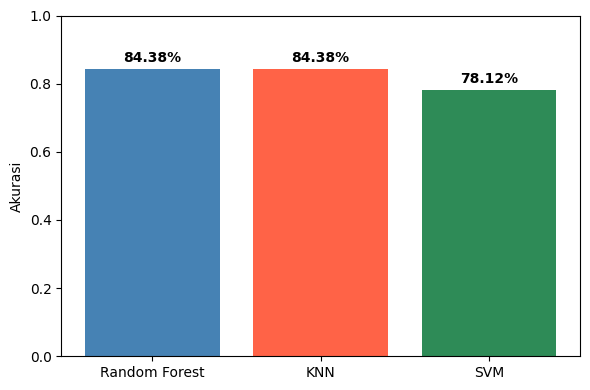

In [20]:
hasil_akurasi = {
    'Random Forest': accuracy_score(y_test, rf.predict(X_test)),
    'SVM':           accuracy_score(y_test, svm.predict(X_test)),
    'KNN':           accuracy_score(y_test, knn.predict(X_test)),
}

df_akurasi = pd.DataFrame(list(hasil_akurasi.items()), columns=['Model', 'Akurasi'])
df_akurasi = df_akurasi.sort_values('Akurasi', ascending=False).reset_index(drop=True)
print(df_akurasi.to_string(index=False))

plt.figure(figsize=(6, 4))
plt.bar(df_akurasi['Model'], df_akurasi['Akurasi'], color=['steelblue', 'tomato', 'seagreen'])
plt.ylim(0, 1)
plt.ylabel('Akurasi')
for i, acc in enumerate(df_akurasi['Akurasi']):
    plt.text(i, acc + 0.02, f'{acc:.2%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Evaluation With Confusion Matrix

Kode ini digunakan untuk mendefinisikan sebuah fungsi pembantu visualisasi dan memanfaatkannya untuk menampilkan matriks kontingensi (confusion matrix) dari tiga model klasifikasi (Random Forest, SVM, dan KNN) pada subset data uji (testing set). Pertama, sebuah fungsi bernama plot_confusion_matrix didefinisikan dengan menerima tiga parameter input, yaitu y_true (label aktual), y_pred (label hasil prediksi), dan title (judul grafik). Di dalam fungsi ini, matriks evaluasi dihitung terlebih dahulu menggunakan fungsi confusion_matrix(y_true, y_pred) dan disimpan dalam variabel cm. Kemudian, kelas ConfusionMatrixDisplay dipanggil untuk membungkus matriks tersebut agar siap divisualisasikan. Grafik matriks digambar menggunakan metode disp.plot(), dengan menerapkan skema gradasi warna biru lewat parameter cmap=plt.cm.Blues. Judul grafik disesuaikan berdasarkan teks parameter yang diterima menggunakan plt.title(), lalu grafik ditampilkan ke layar lewat perintah plt.show().

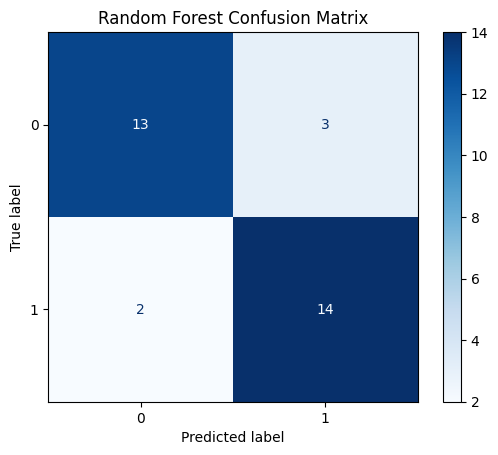

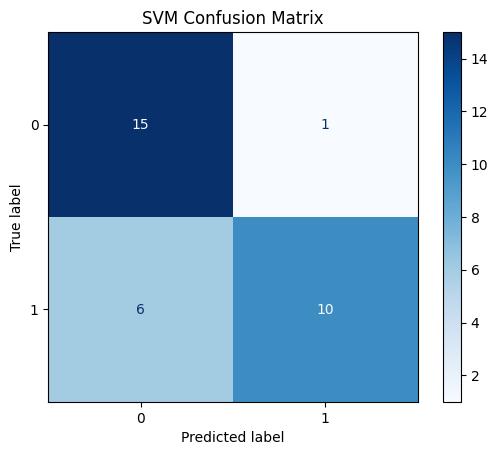

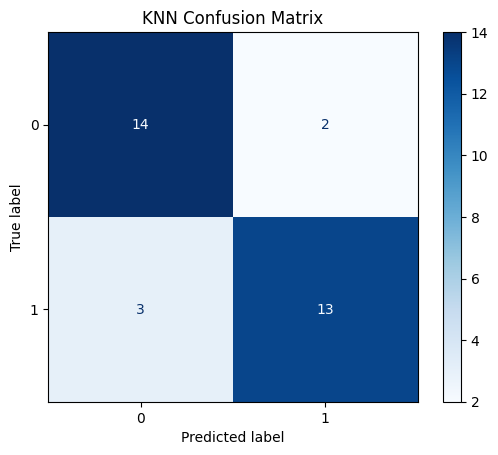

In [21]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")